<img src="http://www.cidaen.es/assets/img/mCIDaeNnb.png" alt="Logo CiDAEN" align="right">


<br><br><br><br>

<h1><font color="#00586D" size=5>Entrenamiento de YOLOv8 sobre el conjunto de tickets de supermercado</font></h1>
<br><br>


<div align="right">
<font color="#00586D" size=3>Javier de la Ossa</font><br>
<font color="#00586D" size=3>Máster en Ciencia de Datos e Ingeniería de Datos en la Nube</font><br>
<font color="#00586D" size=3>Universidad de Castilla-La Mancha</font>

</div>

---
<a id="indice"></a>
<h2><font color="#00586D" size=5>Índice</font></h2>


* [1. Entrenamiento de YOLOv8](#section1)
* [2. Gráficas de evaluación del modelo](#section2)
* [3. Pruebas sobre en conjunto de validación](#section3)
* [4. Predicciones sobre en conjunto de test](#section4)
* [5. Conversión de imagen a texto (OCR)](#section5)

<br>

---

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive

/content/drive/MyDrive


In [3]:
%cd automatic-receipts-recognition
!pip install ultralytics
from ultralytics import YOLO

/content/drive/MyDrive/automatic-receipts-recognition


In [4]:
# Install Pytesseract
!sudo apt-get update
!sudo apt-get install -y tesseract-ocr
!pip install pytesseract

# Install EasyOCR
!pip install easyocr

# Install session info
!pip install session-info

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Ign:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy Release
Hit:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading pac

---

<a id="section1"></a>
## <font color="#00586D"> 1. Entrenamiento de YOLOv8</font>
<br>

In [5]:
# Load pre-trained model
model = YOLO("yolov8n.pt")

# Define training configuration
training_params = {
    "data": "config.yaml",
    "epochs": 650,
    "imgsz": 640,
    "batch": 16,
    "val": True,
    "patience": 100,
    "verbose": True,
    "plots": True
}

# Train the model
results = model.train(**training_params)

Ultralytics YOLOv8.2.86 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=config.yaml, epochs=650, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, l

/usr/local/lib/python3.10/dist-packages/ultralytics/engine/trainer.py:268: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(enabled=self.amp)
train: Scanning /content/drive/MyDrive/automatic-receipts-recognition/data/digital/mercadona/train/labels.cache... 21 images, 0 backgrounds, 0 corrupt: 100%|██████████| 21/21 [00:00<?, ?it/s]


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))


/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
val: Scanning /content/drive/MyDrive/automatic-receipts-recognition/data/digital/mercadona/valid/labels.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]


Plotting labels to runs/detect/train/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.001111, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/detect/train
Starting training for 650 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    641/650      2.23G     0.7297     0.6526     0.8596        163        640: 100%|██████████| 2/2 [00:01<00:00,  1.66it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:02<00:00,  2.93s/it]

                   all          6         91      0.961      0.994      0.995      0.858
EarlyStopping: Training stopped early as no improvement observed in last 100 epochs. Best results observed at epoch 541, best model saved as best.pt.
To update EarlyStopping(patience=100) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



641 epochs completed in 0.159 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics YOLOv8.2.86 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00, 19.65it/s]


                   all          6         91      0.966       0.99      0.994      0.872
      item_description          6         67      0.985      0.949      0.992      0.889
         store_address          6          6      0.965          1      0.995      0.895
            store_name          6          6      0.968          1      0.995      0.821
          total_amount          6          6      0.955          1      0.995      0.865
  transaction_datetime          6          6       0.96          1      0.995      0.892
Speed: 0.1ms preprocess, 1.6ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to runs/detect/train


<a id="section2"></a>
## <font color="#00586D"> 2. Gráficas de evaluación del modelo</font>
<br>

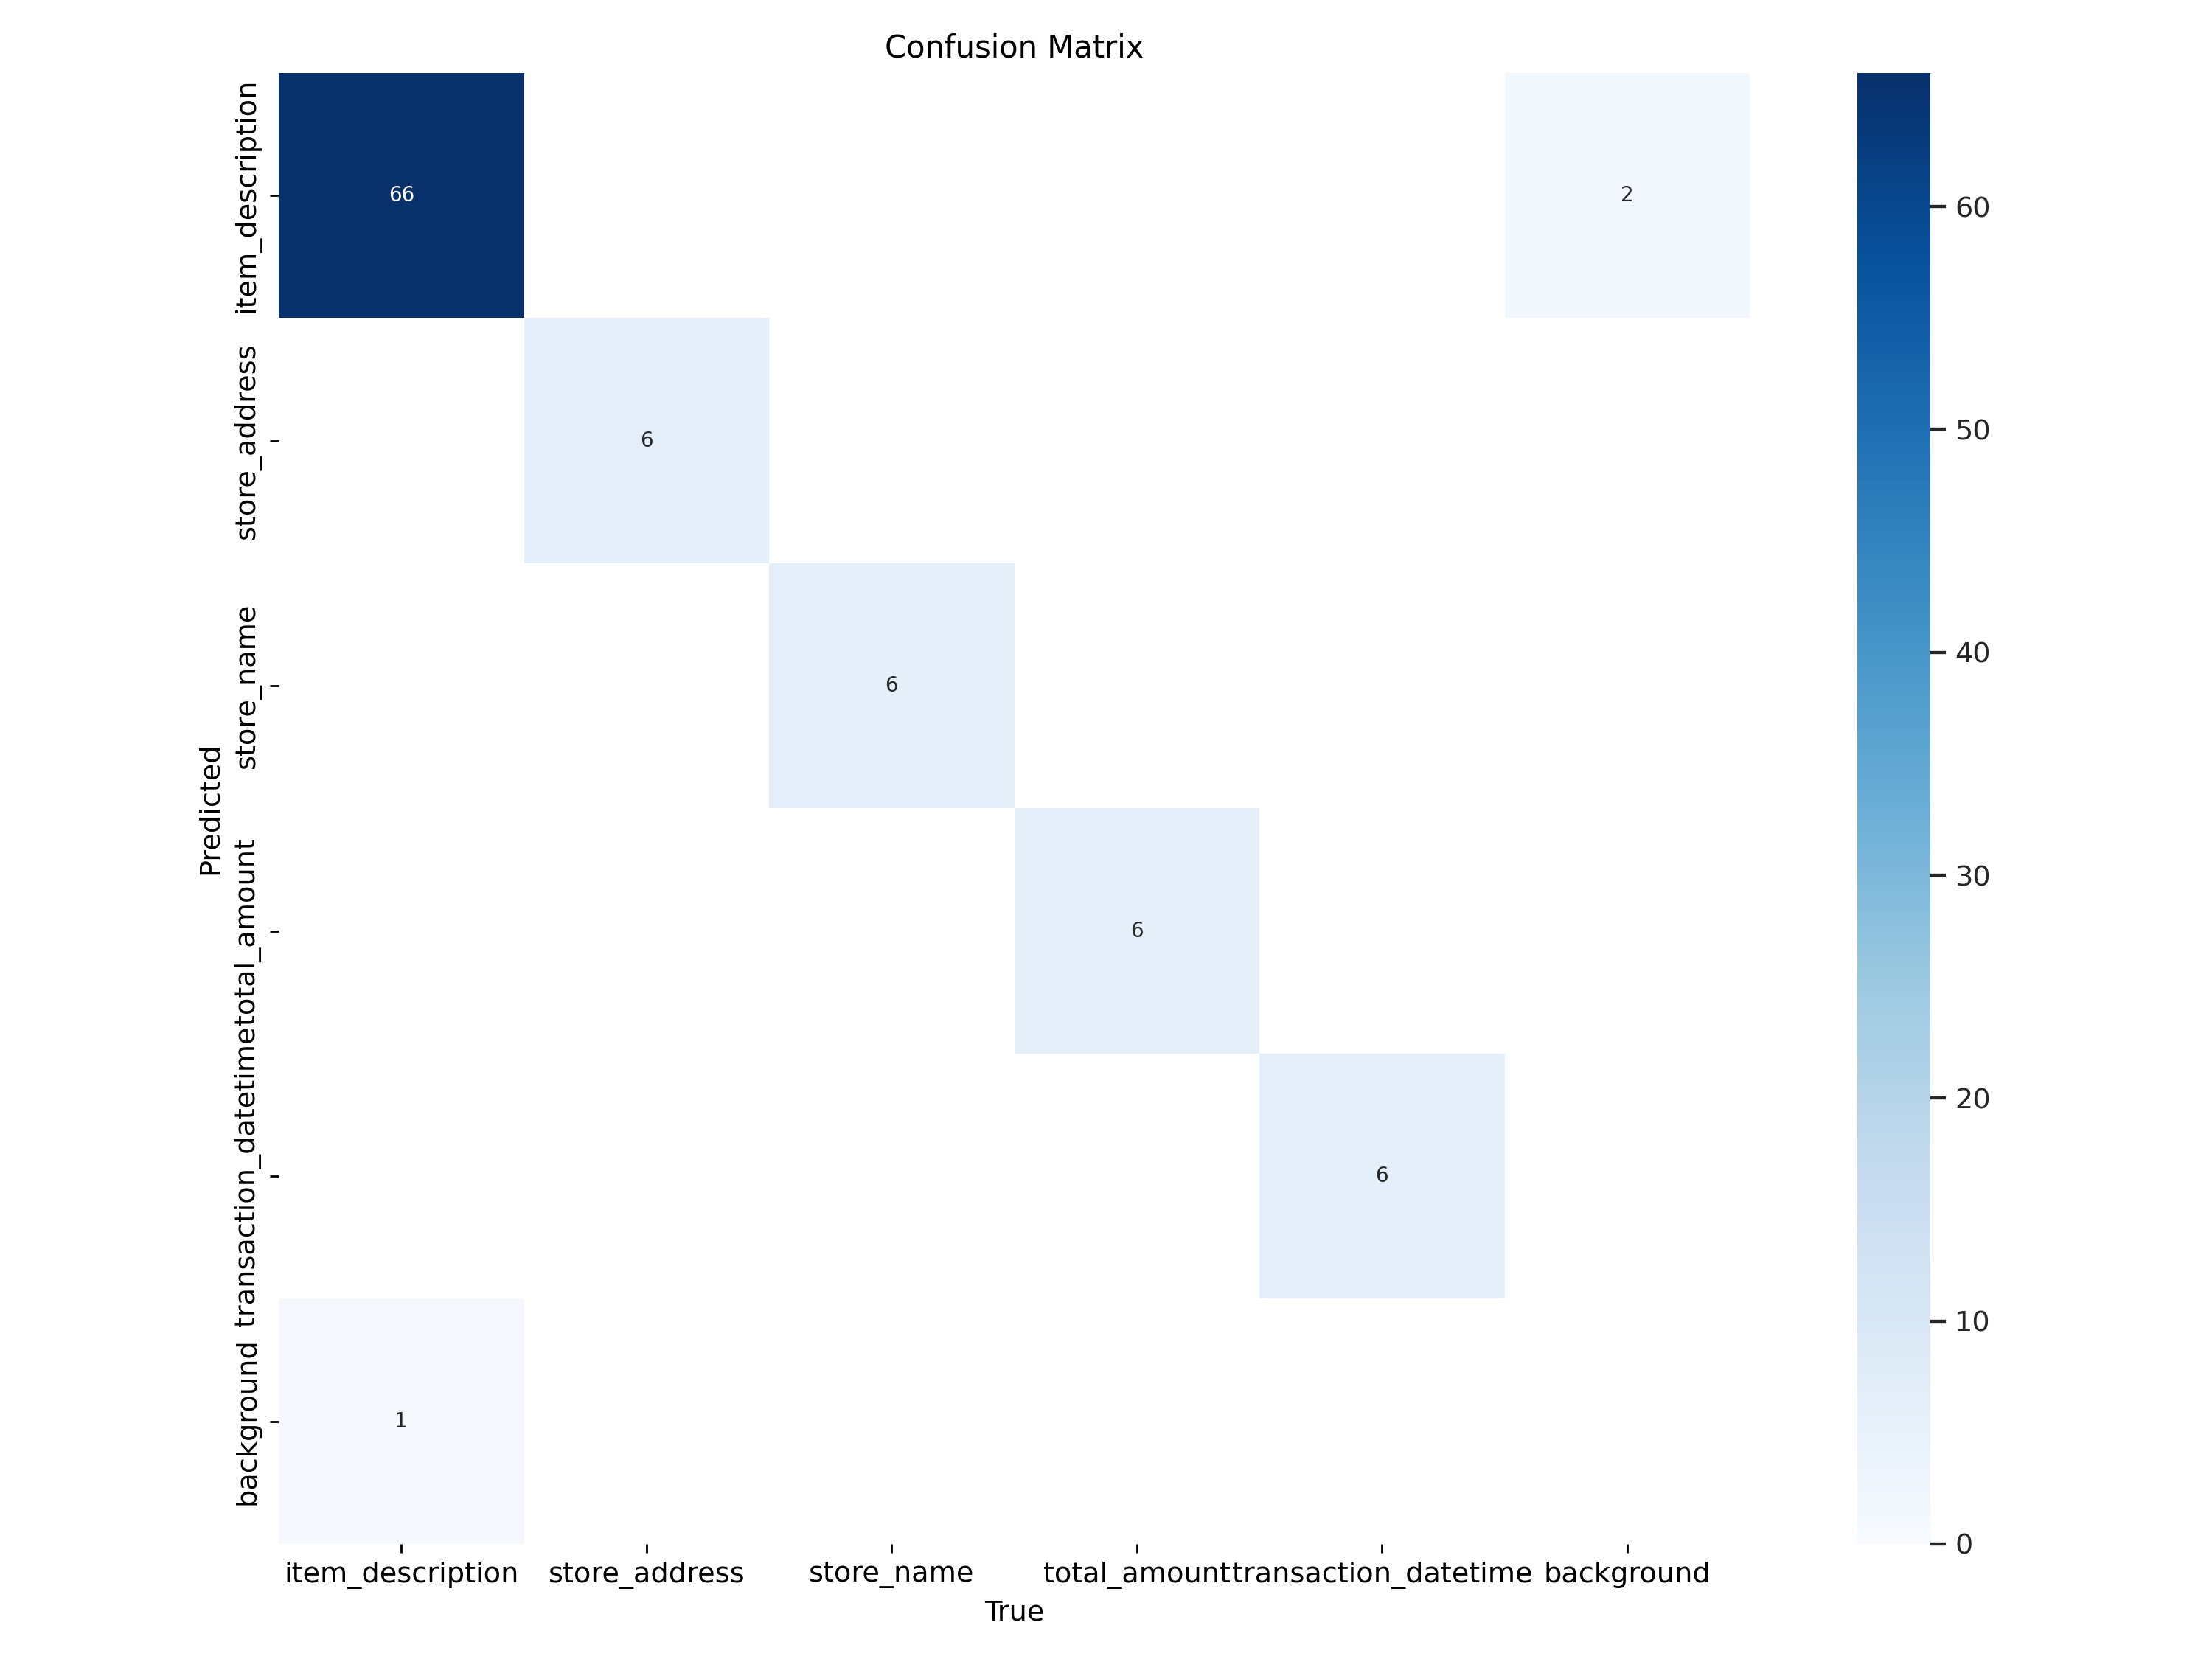

In [6]:
from IPython.display import display, Image

Image("./runs/detect/train/confusion_matrix.png", width=850)

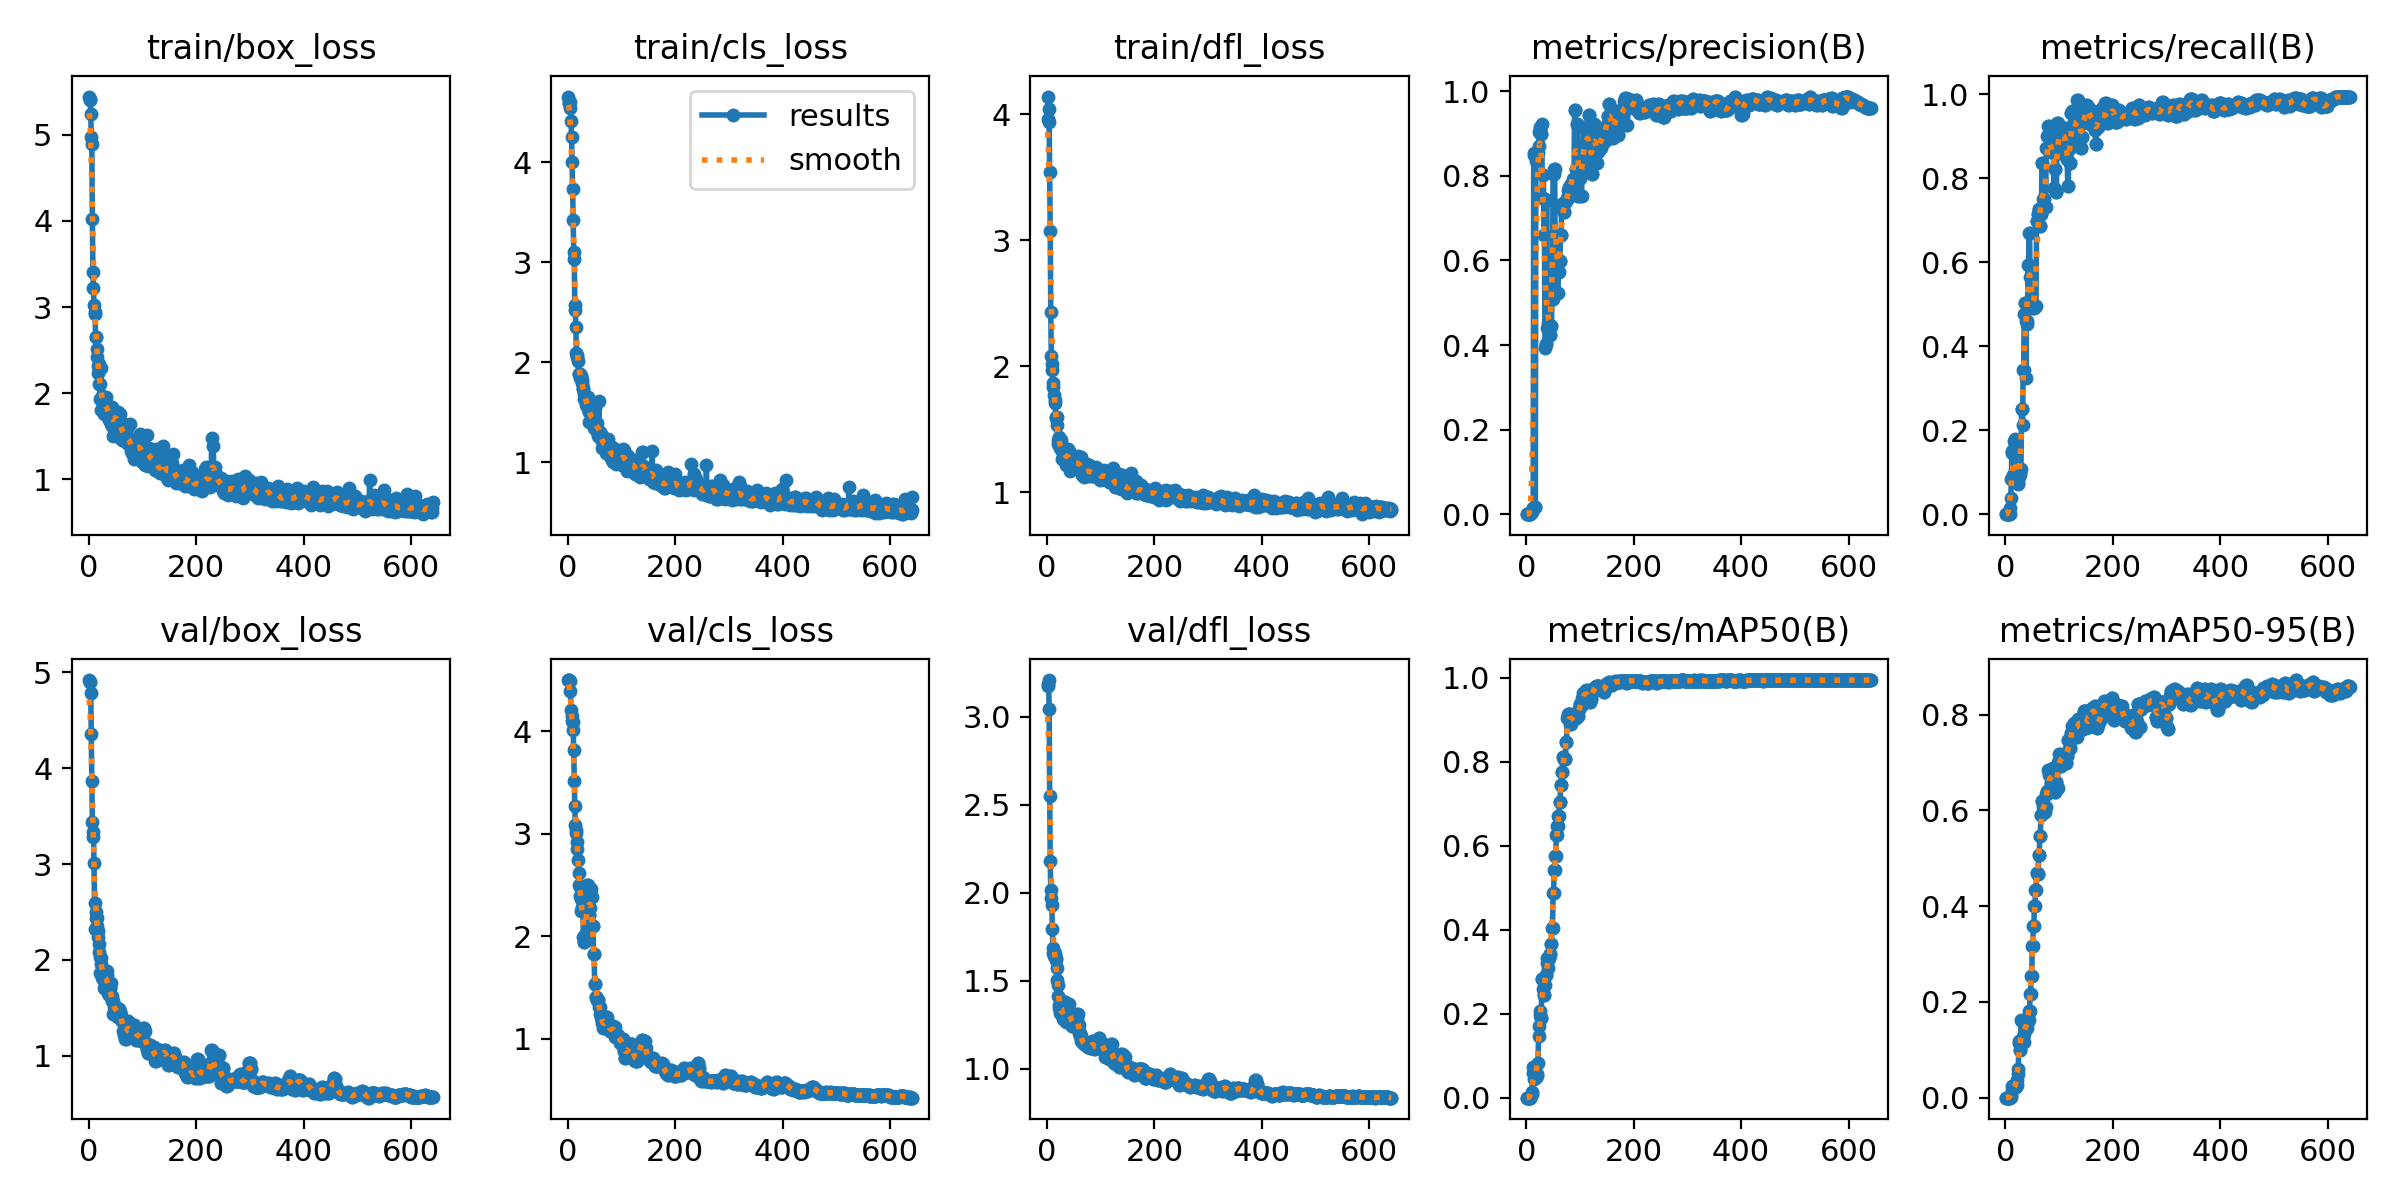

In [7]:
Image("./runs/detect/train/results.png", width=1000)

<a id="section3"></a>
## <font color="#00586D"> 3. Pruebas sobre en conjunto de validación</font>
<br>

In [8]:
model = YOLO("runs/detect/train/weights/best.pt")

metrics = model.val()
metrics.box.map

Ultralytics YOLOv8.2.86 🚀 Python-3.10.12 torch-2.4.0+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs


val: Scanning /content/drive/MyDrive/automatic-receipts-recognition/data/digital/mercadona/valid/labels.cache... 6 images, 0 backgrounds, 0 corrupt: 100%|██████████| 6/6 [00:00<?, ?it/s]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<00:00,  1.81it/s]


                   all          6         91      0.966       0.99      0.995      0.875
      item_description          6         67      0.985      0.948      0.993      0.884
         store_address          6          6      0.965          1      0.995      0.899
            store_name          6          6      0.968          1      0.995      0.821
          total_amount          6          6      0.955          1      0.995      0.897
  transaction_datetime          6          6       0.96          1      0.995      0.875
Speed: 0.4ms preprocess, 20.6ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to runs/detect/val


0.8750667499304567

---

In [9]:
# Import libraries to inspect the results
import cv2
import glob
import json
import numpy as np
import os
import pandas as pd
import random
import re
import torch
import matplotlib.pyplot as plt

---

<a id="section4"></a>
## <font color="#00586D"> 4. Predicciones sobre en conjunto de test</font>
<br>

In [10]:
test_images = glob.glob("./data/digital/mercadona/test/images/*")
test_images

['./data/digital/mercadona/test/images/mercadona_00009_png.rf.016153500a13c8cf8e1ff13c64097c14.jpg',
 './data/digital/mercadona/test/images/mercadona_00024_png.rf.9ae1f4e674336aae3a7aac9f177218a8.jpg',
 './data/digital/mercadona/test/images/mercadona_00005_png.rf.48f6aadd10ac7b48836d3f9f1ee466f0.jpg']

In [11]:
# load the model
model = YOLO("runs/detect/train/weights/best.pt")

In [12]:
# run batched inference on a list of images
results = model(test_images, save=True, show_boxes=True, show_labels=False, show_conf=False)


0: 640x640 15 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 18.7ms
1: 640x640 2 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 18.7ms
2: 640x640 29 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 18.7ms
Speed: 2.4ms preprocess, 18.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


Tomemos un ticket cualquiera para visualizar las predicciones de forma individual:

In [13]:
images_path = "./data/digital/mercadona/images"
image_files = glob.glob(images_path + "/*")
random_image = random.choice(image_files)
random_image

'./data/digital/mercadona/images/mercadona_00027.png'

In [14]:
# Load the image
image_path = random_image

# Load the image using OpenCV
orig_image = cv2.imread(image_path)

# Get the image dimensions
image_height, image_width, _ = orig_image.shape

# Using the YOLO pipeline it's not necessary to resize the image
model_height, model_width = image_height, image_width

x_ratio = image_width / model_width
y_ratio = image_height / model_height

print(f"Original dimensions: {image_width}x{image_height}")

Original dimensions: 1700x5324


In [15]:
# Get predictions
results = model.predict(image_path)


image 1/1 /content/drive/MyDrive/automatic-receipts-recognition/data/digital/mercadona/images/mercadona_00027.png: 640x224 35 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 56.2ms
Speed: 1.8ms preprocess, 56.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 224)


In [16]:
infer = {}

for result in results:
    if "boxes" in result._keys and result.boxes is not None:
        infer["boxes"] = result.boxes.cpu().numpy().data.tolist()

print(infer)

{'boxes': [[1066.379150390625, 3778.125732421875, 1618.7298583984375, 3855.450439453125, 0.9234359860420227, 3.0], [144.66116333007812, 3357.6748046875, 1634.227294921875, 3486.29052734375, 0.8963508605957031, 0.0], [134.64834594726562, 1193.971435546875, 1628.0457763671875, 1265.5648193359375, 0.8949757814407349, 0.0], [392.39501953125, 364.6988525390625, 945.6345825195312, 457.03277587890625, 0.892212450504303, 2.0], [123.95948791503906, 1118.1671142578125, 1624.792236328125, 1194.521728515625, 0.8875390291213989, 0.0], [135.75851440429688, 2421.06005859375, 1630.182373046875, 2490.13134765625, 0.8828287720680237, 0.0], [129.70401000976562, 3067.4560546875, 1633.3197021484375, 3137.168212890625, 0.8811252117156982, 0.0], [134.1300811767578, 2563.74951171875, 1638.26708984375, 2634.184814453125, 0.8799612522125244, 0.0], [136.7068328857422, 2060.853515625, 1626.7042236328125, 2130.284912109375, 0.8794646263122559, 0.0], [136.07318115234375, 1269.793212890625, 1624.8714599609375, 1339.

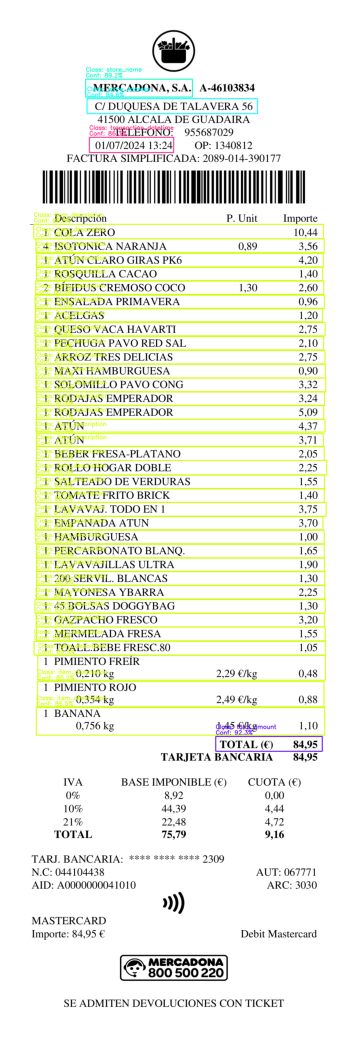

In [17]:
classes_mapper = {0: "item_description", 1: "store_address", 2: "store_name", 3: "total_amount", 4: "transaction_datetime"}

img_with_boxes = orig_image.copy()

if "boxes" in infer:
    for idx, (x1, y1, x2, y2, conf, lbl) in enumerate(infer["boxes"]):
        if conf < 0.6:
            continue
        # Scale bounding box coordinates back to the original image size
        x1, x2 = int(x_ratio * x1), int(x_ratio * x2)
        y1, y2 = int(y_ratio * y1), int(y_ratio * y2)

        # Map label int with its text value
        lbl_name = classes_mapper.get(lbl)

        # Choose a color for the bounding box
        if lbl_name == "item_description":
            color = (0, 255, 206)
        elif lbl_name == "store_address":
            color = (255, 255, 0)
        elif lbl_name == "store_name":
            color = (199, 252, 0)
        elif lbl_name == "total_amount":
            color = (254, 0, 86)
        else:
            color = (134, 34, 255)

        # Draw the bounding box
        cv2.rectangle(img_with_boxes, (x1, y1), (x2, y2), color, 4)

        # Put label and confidence on the image
        cv2.putText(img_with_boxes, f"Class: {lbl_name}", (x1, y1 - 40), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)
        cv2.putText(img_with_boxes, f"Conf: {conf * 100:.1f}%", (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

dpi = 400
figsize = (image_width / dpi, image_height / dpi)

# Display the image with bounding boxes
plt.figure(figsize=figsize)
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis("off")  # Turn off axis
plt.show()

<a id="section5"></a>
## <font color="#00586D"> 5. Conversión de imagen a texto (OCR)</font>

### <font color="#00586D"> 5.1 Almacenamiento de los *crops* de las clases predecidas</font>
<br>

In [18]:
# run batched inference on a list of images
results = model(test_images, save=True, show_boxes=True, show_labels=False, show_conf=False)


0: 640x640 15 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 3.0ms
1: 640x640 2 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 3.0ms
2: 640x640 29 item_descriptions, 1 store_address, 1 store_name, 1 total_amount, 1 transaction_datetime, 3.0ms
Speed: 2.8ms preprocess, 3.0ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict


In [19]:
predictions = glob.glob("./runs/detect/predict/*")
predictions

['./runs/detect/predict/mercadona_00009_png.rf.016153500a13c8cf8e1ff13c64097c14.jpg',
 './runs/detect/predict/mercadona_00024_png.rf.9ae1f4e674336aae3a7aac9f177218a8.jpg',
 './runs/detect/predict/mercadona_00005_png.rf.48f6aadd10ac7b48836d3f9f1ee466f0.jpg']

In [20]:
for prediction in predictions:
  display(Image(prediction, width=320))
  print()

Output hidden; open in https://colab.research.google.com to view.

In [21]:
for result in results:
  result_path = result.path.split("/")[-1]
  result.save_crop(save_dir=f"./crops/{result_path}", file_name=f"detection")

### <font color="#00586D"> 5.2 Comparación de modelos de OCR y diseño de la estructura de datos para cada ticket</font>
<br>

Vamos a hacer pruebas utilizando dos modelos diferentes de reconocimiento de caracteres, **Pytesseract** y **EasyOCR**. La intención de estas pruebas es medir el rendimiento de ambos modelos frente a diferentes tickets de compra.

In [22]:
from PIL import Image
import pytesseract
import easyocr

reader = easyocr.Reader(["es", "en"])

STORE_ADDRESS:


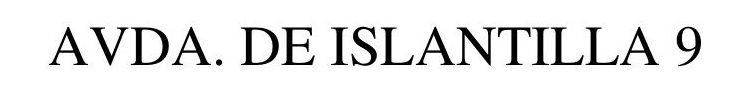

Pytesseract prediction: AVDA. DE ISLANTILLA 9

EasyOCR prediction: AVDA. DE ISLANTILLA 9

TRANSACTION_DATETIME:


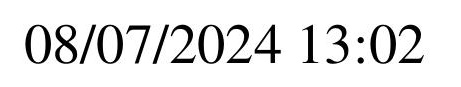

Pytesseract prediction: 08/07/2024 13:02

EasyOCR prediction: 08/07/2024 13.02

TOTAL_AMOUNT:


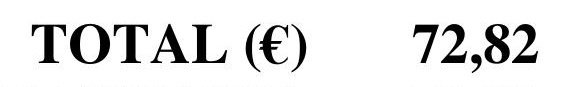

Pytesseract prediction: TOTAL (€) 72,82

EasyOCR prediction: TOTAL (€) 72,82

STORE_NAME:


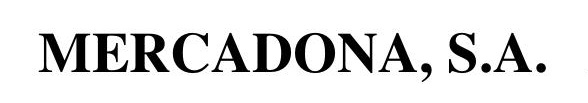

Pytesseract prediction: MERCADONA, S.A.

EasyOCR prediction: MERCADONA, S.A.



In [23]:
CROPS_DIR = "./crops"

last_receipt_folder = glob.glob(f"{CROPS_DIR}/*")[-1]
classes_folders = glob.glob(f"{last_receipt_folder}/*")

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label != "item_description":
    print(f"{class_label.upper()}:")
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      img = Image.open(crop_path)
      display(img)

      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      print(f"Pytesseract prediction: {text}")

      # EasyOCR
      result = reader.readtext(crop_path, detail=0)
      print(f"EasyOCR prediction: {' '.join(result)}")

    print()

In [24]:
receipt_data = {}

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label != "item_description":
    crops_list = glob.glob(f"{class_folder}/*")
    crop_path = crops_list[0]                                       # If there is more than one, takes just the first one
    text = pytesseract.image_to_string(crop_path, lang="eng+spa")
    receipt_data[class_label] = text

print(receipt_data)

{'store_address': 'AVDA. DE ISLANTILLA 9\n\x0c', 'transaction_datetime': '08/07/2024 13:02\n\x0c', 'total_amount': 'TOTAL (€) 72,82\n\x0c', 'store_name': 'MERCADONA, S.A.\n\x0c'}


In [25]:
items = []

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label == "item_description":
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      cleaned_text = re.sub(r"[\x0c\n]", "", text)
      print(f"Pytesseract prediction: {cleaned_text}")

      # EasyOCR
      results = reader.readtext(crop_path, detail=0)
      print(f"EasyOCR prediction: {' '.join(results)}")

      print("======================================================")
      print()

Pytesseract prediction: 1 PECHUGA FINAS HIERB. 3,66
EasyOCR prediction: 1 PECHUGA FINAS HIERB . 3,66

Pytesseract prediction: 1 FRIEGASUELOS PINO 0,95
EasyOCR prediction: 1 FRIEGASUELOS PINO 0,95

Pytesseract prediction: 1 MAYONESA 460ML 1,25
EasyOCR prediction: MAYONESA 46OML 1,25

Pytesseract prediction: 1 LINGUINE 0,79
EasyOCR prediction: 1 LINGUINE 0,79

Pytesseract prediction: 1 ROLLO HOGAR DOBLE 2,25
EasyOCR prediction: 1 ROLLO HOGAR DOBLE 2,25

Pytesseract prediction: 1 BEBER FRESA-PLATANO 2,05
EasyOCR prediction: 1 BEBER FRESA-PLATANO 2 5 05

Pytesseract prediction: 1 RODAJAS EMPERADOR 4,04
EasyOCR prediction: 1 RODAJAS EMPERADOR 4,04

Pytesseract prediction: 1 LOTE BAYETAS SUAVES 1,20
EasyOCR prediction: 1 LOTE BAYETAS SUAVES 1,20

Pytesseract prediction: 1 RODAJAS EMPERADOR4,52
EasyOCR prediction: 1 RODAJAS EMPERADOR 4,52

Pytesseract prediction:  2 BOLSA PLASTICO 0,15 0,30
EasyOCR prediction: 2 BOLSA PLASTICO 0,15 0,30

Pytesseract prediction: 1 FREGONA RESIS. DUPLO 1,75
Eas

In [26]:
items = []

pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]

  if class_label == "item_description":
    crops_list = glob.glob(f"{class_folder}/*")

    for crop_path in crops_list:
      # Pytesseract
      text = pytesseract.image_to_string(crop_path, lang="eng+spa")
      pytesseract_text = re.sub(r"[\x0c\n]", "", text)

      match = re.match(pattern, pytesseract_text)

      if match:
        quantity = match.group(1) if match.group(1) else "N/A" # quantity is optional
        description = match.group(2).strip()  # stip any leading/trailing whitespace
        price = match.group(3) if match.group(3) else "N/A" # price is optional
      else:
        continue

      print(f"Detected text: {pytesseract_text}")
      print(f"- Quantity: {quantity}")
      print(f"- Description: {description}")
      print(f"- Price: {price}")

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price": price
      }

      items.append(item_dict)

      print("------------------------------------------------------")

      # EasyOCR
      results = reader.readtext(crop_path, detail=0)
      easyocr_text = " ".join(results)

      match = re.match(pattern, easyocr_text)
      print(f"Regular expression match result (EasyOCR): {match}")
      print(f"EasyOCR prediction: {easyocr_text}")

      print("======================================================")
print()

Detected text: 1 PECHUGA FINAS HIERB. 3,66
- Quantity: 1
- Description: PECHUGA FINAS HIERB.
- Price: 3,66
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 28), match='1 PECHUGA FINAS HIERB . 3,66'>
EasyOCR prediction: 1 PECHUGA FINAS HIERB . 3,66
Detected text: 1 FRIEGASUELOS PINO 0,95
- Quantity: 1
- Description: FRIEGASUELOS PINO
- Price: 0,95
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 24), match='1 FRIEGASUELOS PINO 0,95'>
EasyOCR prediction: 1 FRIEGASUELOS PINO 0,95
Detected text: 1 MAYONESA 460ML 1,25
- Quantity: 1
- Description: MAYONESA 460ML
- Price: 1,25
------------------------------------------------------
Regular expression match result (EasyOCR): <re.Match object; span=(0, 19), match='MAYONESA 46OML 1,25'>
EasyOCR prediction: MAYONESA 46OML 1,25
Detected text: 1 LINGUINE 0,79
- Quantity: 1
- Description: LINGUINE
- P

Es necesario organizar la información extraída de los tickets en un formato de datos estructurado que permita un fácil acceso y procesamiento. La estructura de datos seleccionada está diseñada para capturar tanto los detalles generales del ticket, como el nombrel comercio, la dirección, el importe total y la fecha y hora de la transacción, así como los artículos individuales comprados.

La elección de esta estructura en formato de diccionario (JSON) permite agrupar la información relacionada de manera lógica:

```
data = {
  "store_name": store_name,
  "store_address": store_address,
  "total_amount": total_amount,
  "transaction_datetime": transaction_datetime,
  "items": [
    {"quantity": item_quantity, "description": item_desc, "price": price},
    {"quantity": item_quantity, "description": item_desc, "price": price},
    {"quantity": item_quantity, "description": item_desc, "price": price},
    ...
  ]
}
```

In [27]:
import pytesseract

def pytesseract_text_extraction(image_path: str, lang: str = "eng+spa") -> str:
    """
    Extracts text from an image using pytesseract and cleans it by removing unwanted characters.

    :param image_path (str): Path to the image file.
    :param lang (str): Language(s) to be used by pytesseract for OCR. Default is "eng+spa".
    :return cleaned_text (str): The extracted and cleaned text.
    """
    # Perform OCR to extract text
    text = pytesseract.image_to_string(image_path, lang=lang)

    # Clean the text by removing unwanted characters
    cleaned_text = re.sub(r"[\x0c\n]", "", text)

    return cleaned_text

In [28]:
receipt_data = {}

total_amount_pattern = r"(\d+[.,]?\d+)"
items_pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]
  crops_list = glob.glob(f"{class_folder}/*")

  if class_label != "item_description":
    crop_path = crops_list[0] # If there is more than one, takes just the first one
    cleaned_text = pytesseract_text_extraction(crop_path)

    if class_label == "total_amount":
      match = re.search(total_amount_pattern, cleaned_text)
      if match:
        cleaned_text = float(match.group(1).replace(",", "."))

    receipt_data[class_label] = cleaned_text

  else:
    items = []

    for crop_path in crops_list:
      cleaned_text = pytesseract_text_extraction(crop_path)

      match = re.match(items_pattern, cleaned_text)

      if match:
        quantity = int(match.group(1)) if match.group(1) else 1 # quantity is optional. Criteria is 1 in case no match
        description = match.group(2).strip()  # strip any leading/trailing whitespace
        price = float(match.group(3).replace(",", ".")) if match.group(3) else None # price is optional
      else:
        continue

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price_eur": price
      }

      items.append(item_dict)

    receipt_data["items"] = items

print(json.dumps(receipt_data, indent=4))

{
    "items": [
        {
            "quantity": 1,
            "description": "PECHUGA FINAS HIERB.",
            "price_eur": 3.66
        },
        {
            "quantity": 1,
            "description": "FRIEGASUELOS PINO",
            "price_eur": 0.95
        },
        {
            "quantity": 1,
            "description": "MAYONESA 460ML",
            "price_eur": 1.25
        },
        {
            "quantity": 1,
            "description": "LINGUINE",
            "price_eur": 0.79
        },
        {
            "quantity": 1,
            "description": "ROLLO HOGAR DOBLE",
            "price_eur": 2.25
        },
        {
            "quantity": 1,
            "description": "RODAJAS EMPERADOR",
            "price_eur": 4.04
        },
        {
            "quantity": 1,
            "description": "LOTE BAYETAS SUAVES",
            "price_eur": 1.2
        },
        {
            "quantity": 1,
            "description": "RODAJAS EMPERADOR",
            "price_eur":

In [29]:
receipt_details = {key: value for key, value in receipt_data.items() if key != "items"}

df_receipt_details = pd.DataFrame([receipt_details])
df_receipt_items = pd.DataFrame(receipt_data["items"])

pd.concat([df_receipt_details, df_receipt_items], axis=1).ffill()

,store_address,transaction_datetime,total_amount,store_name,quantity,description,price_eur
0,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,PECHUGA FINAS HIERB.,3.66
1,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,FRIEGASUELOS PINO,0.95
2,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,MAYONESA 460ML,1.25
3,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,LINGUINE,0.79
4,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,ROLLO HOGAR DOBLE,2.25
5,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,RODAJAS EMPERADOR,4.04
6,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,LOTE BAYETAS SUAVES,1.20
7,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,RODAJAS EMPERADOR,4.52
8,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,"2 BOLSA PLASTICO 0,15",0.30
9,AVDA. DE ISLANTILLA 9,08/07/2024 13:02,72.82,"MERCADONA, S.A.",1,FREGONA RESIS. DUPLO,1.75


In [30]:
def easyocr_text_extraction(reader: easyocr.easyocr.Reader, image_path: str) -> str:
    """
    Extracts text from an image using EasyOCR and return a string will all the extractions
    separated by a space.

    :param reader (easyocr.easyocr.Reader): EasyOCR model.
    :param image_path (str): Language(s) to be used by pytesseract for OCR. Default is "eng+spa".
    :return cleaned_text (str): The extracted and cleaned text.
    """

    # Perform OCR to extract text
    results = reader.readtext(image_path, detail=0)

    # Join all the text bits together
    cleaned_text = " ".join(results)

    return cleaned_text

In [31]:
receipt_data = {}

total_amount_pattern = r"(\d+[.,]?\d+)"
items_pattern = r"^(\d*)\s*([A-Za-z\s.,/-ÁÉÍÓÚÑáéíóúñ]+?)(\d+[.,]?\d*)$"

for class_folder in classes_folders:
  class_label = class_folder.split("/")[-1]
  crops_list = glob.glob(f"{class_folder}/*")

  if class_label != "item_description":
    crop_path = crops_list[0] # If there is more than one, takes just the first one

    cleaned_text = easyocr_text_extraction(reader, crop_path)

    if class_label == "total_amount":
      match = re.search(total_amount_pattern, cleaned_text)
      if match:
        cleaned_text = float(match.group(1).replace(",", "."))

    receipt_data[class_label] = cleaned_text

  else:
    items = []

    for crop_path in crops_list:
      cleaned_text = easyocr_text_extraction(reader, crop_path)

      match = re.match(items_pattern, cleaned_text)

      if match:
        quantity = int(match.group(1)) if match.group(1) else 1 # quantity is optional. Criteria is 1 in case no match
        description = match.group(2).strip()  # strip any leading/trailing whitespace
        price = float(match.group(3).replace(",", ".")) if match.group(3) else None # price is optional
      else:
        continue

      item_dict = {
          "quantity": quantity,
          "description": description,
          "price_eur": price
      }

      items.append(item_dict)

    receipt_data["items"] = items

print(json.dumps(receipt_data, indent=4))

{
    "items": [
        {
            "quantity": 1,
            "description": "PECHUGA FINAS HIERB .",
            "price_eur": 3.66
        },
        {
            "quantity": 1,
            "description": "FRIEGASUELOS PINO",
            "price_eur": 0.95
        },
        {
            "quantity": 1,
            "description": "MAYONESA 46OML",
            "price_eur": 1.25
        },
        {
            "quantity": 1,
            "description": "LINGUINE",
            "price_eur": 0.79
        },
        {
            "quantity": 1,
            "description": "ROLLO HOGAR DOBLE",
            "price_eur": 2.25
        },
        {
            "quantity": 1,
            "description": "RODAJAS EMPERADOR",
            "price_eur": 4.04
        },
        {
            "quantity": 1,
            "description": "LOTE BAYETAS SUAVES",
            "price_eur": 1.2
        },
        {
            "quantity": 1,
            "description": "RODAJAS EMPERADOR",
            "price_eur"

In [32]:
import session_info
session_info.show(html=False)

-----
PIL                 9.4.0
cv2                 4.10.0
easyocr             1.7.1
google              NA
matplotlib          3.7.1
numpy               1.26.4
pandas              2.1.4
pytesseract         0.3.13
session_info        1.0.0
torch               2.4.0+cu121
ultralytics         8.2.86
-----
IPython             7.34.0
jupyter_client      6.1.12
jupyter_core        5.7.2
notebook            6.5.5
-----
Python 3.10.12 (main, Jul 29 2024, 16:56:48) [GCC 11.4.0]
Linux-6.1.85+-x86_64-with-glibc2.35
-----
Session information updated at 2024-09-02 17:01


---